In [100]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt

In [6]:
def ou_2d(T,dt, theta, sigma):
    # T = length of sequence
    # dt = time step size
    # sigma = how noisy it is
    # theta = how strongly it pulls towards center 

    x=np.zeros((T,2))
    x[0] = np.random.randn(2) #random initial condition

    for t in range (1,T):
        dW = np.sqrt(dt) * np.random.randn(2)
        x[t] = x[t-1] - theta*x[t-1]*dt+ sigma*dW #OU SDE
    
    return x

In [ ]:
def make_training_pairs(sequence, k):
    #k = context length

    inputs = [] #last k points
    targets = [] # next point

    for t in range(k, len(sequence)):
        inputs.append(sequence[t-k:t])
        targets.append(sequence[t])

    return np.array(inputs), np.array(targets)

In [105]:
T = 1000
dt = 0.01
theta = 0.5
sigma = 0.3
seq = ou_2d(T,dt,theta,sigma)
print(seq.shape)

(1000, 2)


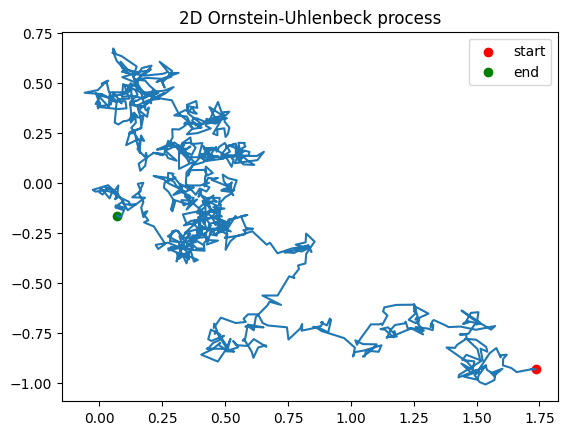

In [65]:
plt.plot(seq[:,0], seq[:,1]) #seq[:,0] = x-coord, seq[:,1] = y-coord
plt.scatter(seq[0,0], seq[0,1], color='red', label='start')
plt.scatter(seq[-1,0], seq[-1,1], color='green', label='end')  # end
plt.legend()
plt.title("2D Ornstein-Uhlenbeck process")
plt.show()

In [106]:
def generate_dataset(num_sequences):
    return[ou_2d(T,dt,theta,sigma) for _ in range(num_sequences)]

In [101]:
def prepare_dataset(sequences, k):
    X_all, Y_all = [], []
    
    for seq in sequences:
        # make input-target pairs for this sequence
        inputs, targets = make_training_pairs(seq, k)
        X_all.append(inputs)
        Y_all.append(targets)
    
    # stack everything into one big dataset
    X_all = np.vstack(X_all)
    Y_all = np.vstack(Y_all)
    
    return X_all, Y_all


In [107]:
num_sequences = 50
sequences = generate_dataset(num_sequences)

k = 20
X_all, Y_all = prepare_dataset(sequences, k)

print("X_all shape:", X_all.shape)  # -> (num_sequences*(T-k), k, 2)
print("Y_all shape:", Y_all.shape)  # -> (num_sequences*(T-k), 2)


X_all shape: (49000, 20, 2)
Y_all shape: (49000, 2)


In [108]:
X_tensor = torch.tensor(X_all, dtype=torch.float32)
Y_tensor = torch.tensor(Y_all, dtype=torch.float32)

dataset = TensorDataset(X_tensor, Y_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

In [109]:
class Transformer(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, dim_feedforward):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model) #project 2D input to d_model
        self.pos_enc = nn.Parameter(torch.randn(1,1000,d_model)) #simple learned positional encoding
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead = nhead, dim_feedforward=dim_feedforward, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, input_dim) #project back to 2D

    def forward(self, x):
        #x = [batch, seq_len, input_dim]
        x=self.input_proj(x)
        x = x + self.pos_enc[:, x.size(1), :] #add positional encoding
        x = self.transformer(x) # transformer expects [seq_len, batch, d_model]
        x = x[:, -1, :] #take output of last token
        x = self.output_proj(x)
        return x

In [110]:
model = Transformer(2, 32, 4, 2, 64)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss() # predicting continuous values
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [112]:
num_epochs = 10

for epoch in range(num_epochs):
    total_loss = 0
    for x_batch, y_batch in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)
    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")

Epoch 1/10, Loss: 0.001078
Epoch 2/10, Loss: 0.001077
Epoch 3/10, Loss: 0.001080
Epoch 4/10, Loss: 0.001044
Epoch 5/10, Loss: 0.001037
Epoch 6/10, Loss: 0.001047
Epoch 7/10, Loss: 0.001036
Epoch 8/10, Loss: 0.001016
Epoch 9/10, Loss: 0.001010
Epoch 10/10, Loss: 0.001007


In [113]:
seq_len = 1000  # length of generated sequence
context = torch.tensor(seq[:k], dtype=torch.float32).unsqueeze(0).to(device)  # start with initial context
generated = context.clone()

for _ in range(seq_len - k):
    next_point = model(context)
    generated = torch.cat([generated, next_point.unsqueeze(1)], dim=1)
    context = generated[:, -k:, :]  # slide window

gen_seq = generated.squeeze(0).cpu().detach().numpy()

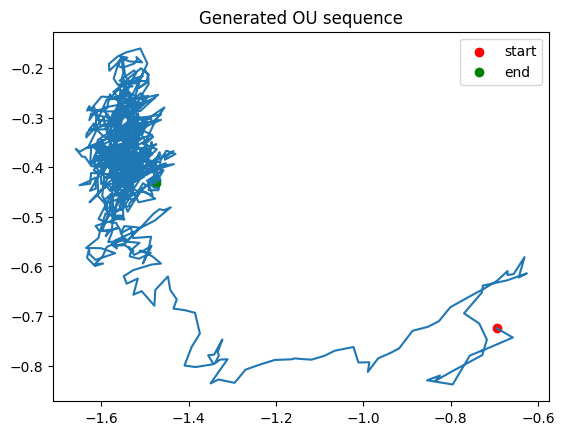

In [114]:
plt.plot(gen_seq[:,0], gen_seq[:,1])
plt.scatter(gen_seq[0,0], gen_seq[0,1], color='red', label='start')
plt.scatter(gen_seq[-1,0], gen_seq[-1,1], color='green', label='end')
plt.legend()
plt.title("Generated OU sequence")
plt.show()